In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [2]:

from pyprojroot import here

import importlib.util

_spec = importlib.util.spec_from_file_location("opinion_functions", here() / "src" / "opinion_functions.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
fun = _mod

_spec = importlib.util.spec_from_file_location("generate_homophilic_graph_symmetric", here() / "src" / "generate_homophilic_graph_symmetric.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
generate_homophilic_graph_symmetric = _mod



In [3]:
modelylim=200
num_swaps=100
homophily=0.75
num_agents=1000
minority_fraction=0.333
majority_fraction=1-minority_fraction
m=5
random.seed(101) #for reproducibility
G,minority_nodes = generate_homophilic_graph_symmetric.homophilic_ba_graph(N=num_agents, m=m, minority_fraction=minority_fraction, homophily=homophily)
dpival=300

true_opinion,perceived_opinion=fun.generate_perceived_opinion(G,minority_nodes,{},narcissistic=False,weigh_connected=False)

minority_opinion = [perceived_opinion[i] for i in minority_nodes]
minority_misperception = [(1-minority_fraction)-perceived_opinion[i] for i in minority_nodes]
majority_opinion = [perceived_opinion[x] for x in np.arange(len(perceived_opinion)) if x not in minority_nodes]
majority_misperception = [(1-minority_fraction)-perceived_opinion[x] for x in np.arange(len(perceived_opinion)) if x not in minority_nodes]

perceived_opinion_percent = [i * 100 for i in perceived_opinion]
majority_opinion_percent=[i * 100 for i in majority_opinion]
minority_opinion_percent=[i * 100 for i in minority_opinion]


for i in range(num_swaps):
    G,new_minority_nodes=fun.swap_top_maj_opinion(G,minority_nodes)
    # print(minority_nodes)
    # print(new_minority_nodes)
    true_opinion,perceived_opinion=fun.generate_perceived_opinion(G,new_minority_nodes,{},narcissistic=False,weigh_connected=False)

    minority_opinion = [perceived_opinion[i] for i in minority_nodes]
    minority_misperception = [(1-minority_fraction)-perceived_opinion[i] for i in minority_nodes]
    majority_opinion = [perceived_opinion[x] for x in np.arange(len(perceived_opinion)) if x not in minority_nodes]
    majority_misperception = [(1-minority_fraction)-perceived_opinion[x] for x in np.arange(len(perceived_opinion)) if x not in minority_nodes]

    perceived_opinion_percent = [i * 100 for i in perceived_opinion]
    majority_opinion_percent=[i * 100 for i in majority_opinion]
    minority_opinion_percent=[i * 100 for i in minority_opinion]

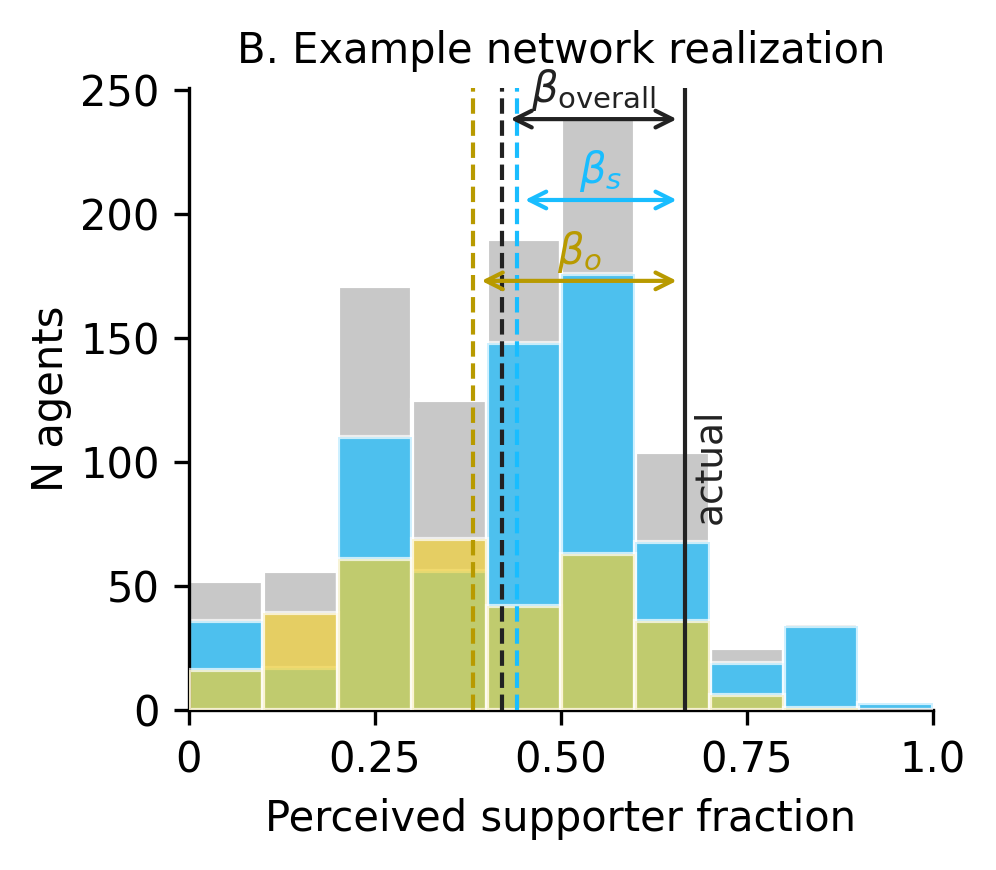

In [4]:
# ── style constants ────────────────────────────────────────────────────────
SMALL_SIZE_H  = 10
MEDIUM_SIZE_H = 10
COL_BLACK     = '#222222'
COL_BAR       = '#c8c8c8'
COL_SUPP      = '#19bdff'
COL_OPP       = '#f2d138'
COL_OPP_DARK  = '#b89a00'
BBOX          = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)

plt.rc('font',   size=SMALL_SIZE_H)
plt.rc('axes',   titlesize=MEDIUM_SIZE_H)
plt.rc('axes',   labelsize=MEDIUM_SIZE_H)
plt.rc('xtick',  labelsize=SMALL_SIZE_H)
plt.rc('ytick',  labelsize=SMALL_SIZE_H)

# ── data ──────────────────────────────────────────────────────────────────
perc_split = np.array(perceived_opinion)
perc_supp  = np.array(majority_opinion)
perc_opp   = np.array(minority_opinion)
fs         = 1 - minority_fraction

mean_all  = perc_split.mean()
mean_supp = perc_supp.mean()
mean_opp  = perc_opp.mean()

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.42, 3.0), dpi=300)
bins_edges = np.linspace(0, 1, 11)

ax.hist(perc_split, bins=bins_edges, histtype='bar',
        color=COL_BAR,  edgecolor='white', alpha=1.0, zorder=1)
ax.hist(perc_supp,  bins=bins_edges, histtype='bar',
        color=COL_SUPP, edgecolor='white', alpha=0.7, zorder=2)
ax.hist(perc_opp,   bins=bins_edges, histtype='bar',
        color=COL_OPP,  edgecolor='white', alpha=0.7, zorder=3)
sns.despine(ax=ax)

ymax_s = ax.get_ylim()[1]

# vertical lines
ax.axvline(fs,        color=COL_BLACK,    linestyle='-',  linewidth=1, zorder=5)
ax.axvline(mean_all,  color=COL_BLACK,    linestyle='--', linewidth=1, zorder=4)
ax.axvline(mean_supp, color=COL_SUPP,     linestyle='--', linewidth=1, zorder=4)
ax.axvline(mean_opp,  color=COL_OPP_DARK, linestyle='--', linewidth=1, zorder=4)

ax.text(fs + 0.01, ymax_s * 0.30, 'actual', rotation=90,
        color=COL_BLACK, fontsize=SMALL_SIZE_H - 1, va='bottom', zorder=5)

# stacked arrows
arrow_y_ov = ymax_s * 0.95
arrow_y_s  = ymax_s * 0.82
arrow_y_o  = ymax_s * 0.69

ax.annotate('', xy=(fs, arrow_y_ov), xytext=(mean_all, arrow_y_ov),
            arrowprops=dict(arrowstyle='<->', color=COL_BLACK, lw=1), zorder=5)
ax.text((mean_all + fs) / 2, arrow_y_ov + ymax_s * 0.01,
        r'$\beta_{\mathrm{overall}}$', ha='center', va='bottom',
        fontsize=SMALL_SIZE_H, color=COL_BLACK, zorder=5)

ax.annotate('', xy=(fs, arrow_y_s), xytext=(mean_supp, arrow_y_s),
            arrowprops=dict(arrowstyle='<->', color=COL_SUPP, lw=1), zorder=5)
ax.text((mean_supp + fs) / 2, arrow_y_s + ymax_s * 0.01,
        r'$\beta_s$', ha='center', va='bottom',
        fontsize=SMALL_SIZE_H, color=COL_SUPP, zorder=5)

ax.annotate('', xy=(fs, arrow_y_o), xytext=(mean_opp, arrow_y_o),
            arrowprops=dict(arrowstyle='<->', color=COL_OPP_DARK, lw=1), zorder=5)
ax.text((mean_opp + fs) / 2, arrow_y_o + ymax_s * 0.01,
        r'$\beta_o$', ha='center', va='bottom',
        fontsize=SMALL_SIZE_H, color=COL_OPP_DARK, zorder=5)

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1.0'])
ax.set_xlabel('Perceived supporter fraction', labelpad=4)
ax.set_ylabel('N agents', labelpad=2)
ax.set_title('B. Example network realization', fontsize=MEDIUM_SIZE_H)

plt.tight_layout()
fig.savefig(str(here() / "figures" / "figure_histogram_example_grouped_swaps.pdf"), dpi=300, bbox_inches='tight')
plt.show()
